In [ ]:
# !pip install -U bitsandbytes transformers accelerate

In [1]:
import os
import sys

path = os.getcwd()
while True:
    if 'utils.py' in os.listdir(path):
        if path not in sys.path:
            sys.path.append(path)
        break
    new_path = os.path.dirname(path)
    if new_path == path:
        print("utils.py not found in any parent folder.")
        break
    path = new_path

import utils
import pandas as pd
from torch.utils.data import DataLoader
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
import torch
from sklearn.model_selection import train_test_split

/opt/anaconda3/envs/nlp/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Global Parameters of Notebook
global_params = {'dataset_type': 'qnli',
                'quantization': '4bit',
                'training_mode': 'few shot',
                'model_id': 'mistralai/Mistral-7B-Instruct-v0.3'}

# Create checkpoint
checkpoint_path = utils.create_checkpoint_path(params=global_params)

Saving to: /Users/giorgosdikaios/Library/Mobile Documents/com~apple~CloudDocs/Desktop/DAMA_EAP/NLI_Study/Notebooks/QNLI_Notebooks/QNLI_Mistral_7B_Instruct_v0_3/Few-Shot/checkpoint_qnli_Mistral_7B_Instruct_v0.3_4bit_few_shot.pt


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
utils.hf_login("HF_TOKEN")

In [ ]:
quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type="nf4"
)

tokenizer = AutoTokenizer.from_pretrained(global_params['model_id'])
model = AutoModelForCausalLM.from_pretrained(
    global_params['model_id'],
    device_map="auto",
    quantization_config=quantization_config,
    attn_implementation="eager"
    )

# Add padding token to the tokenizer and change padding side
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "left"

# Change the model to evaluation mode
model.eval()

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

In [20]:
# from google.colab import files
# uploaded = files.upload()
qnli_val = pd.read_csv('/Users/giorgosdikaios/Library/Mobile Documents/com~apple~CloudDocs/Desktop/DAMA_EAP/NLI_Study/Datasets/QNLI/qnli_val.csv')

qnli_val["label"] = qnli_val["label"].map({0: "entailment", 1: "not entailment"})

qnli_val_idx, prompt_examples_idx = train_test_split(
    qnli_val.index,
    test_size=10,
    stratify=qnli_val["label"],
    random_state=42
)

demo_examples = qnli_val.loc[prompt_examples_idx].reset_index(drop=True)
qnli_val_few_shot = qnli_val.loc[qnli_val_idx].reset_index(drop=True)

In [21]:
demo_examples

,question,sentence,label,idx
0,Where are some of the best medical facilities ...,"Today, Warsaw has some of the best medical fac...",entailment,1788
1,How much rain per year does Fresno get on aver...,Average annual precipitation is around 11.5 in...,entailment,3303
2,Which mobile service were Verizon customers ab...,"Due to Verizon Communications exclusivity, str...",entailment,2632
3,What local radio station is broadcast by the C...,The entrance to studio 5 at the City Road comp...,not entailment,5315
4,When did Tugh Temur die?,"After El Temür's death, Bayan became as powerf...",not entailment,2793
5,Who was the final Prime Minister of East Germany?,"Frederick William, Elector of Brandenburg, inv...",not entailment,2303
6,Is the output of a functional problem typicall...,Notable examples include the traveling salesma...,not entailment,1299
7,What land was ceded to Spain?,France ceded its territory east of the Mississ...,not entailment,3977
8,Which of his future general's fathers helped T...,The Tayichi'ud enslaved Temüjin (reportedly wi...,entailment,2227
9,When are subject committees established?,Subject Committees are established at the begi...,entailment,2296


In [22]:
# Make examples for prompt
prompt_examples = ''
for i in range(len(demo_examples)):
    prompt_examples += f"Example {i+1}\nQuestion: {demo_examples.iloc[i]['question']}\nSentence: {demo_examples.iloc[i]['sentence']}\nAnswer: {demo_examples.iloc[i]['label']} \n\n"

print(prompt_examples)

Example 1
Question: Where are some of the best medical facilities in East-Central Europe located?
Sentence: Today, Warsaw has some of the best medical facilities in Poland and East-Central Europe.
Answer: entailment 

Example 2
Question: How much rain per year does Fresno get on average?
Sentence: Average annual precipitation is around 11.5 inches (292.1 mm), which, by definition, would classify the area as a semidesert.
Answer: entailment 

Example 3
Question: Which mobile service were Verizon customers able to watch Super Bowl 50 on their phones?
Sentence: Due to Verizon Communications exclusivity, streaming on smartphones was only provided to Verizon Wireless customers via the NFL Mobile service.
Answer: entailment 

Example 4
Question: What local radio station is broadcast by the Corporation from the Pink Palace?
Sentence: The entrance to studio 5 at the City Road complex gave its name to the 1980s music television programme, The Tube.
Answer: not entailment 

Example 5
Question: W

In [23]:
qnli_val_few_shot.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5453 entries, 0 to 5452
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   question  5453 non-null   object
 1   sentence  5453 non-null   object
 2   label     5453 non-null   object
 3   idx       5453 non-null   int64 
dtypes: int64(1), object(3)
memory usage: 170.5+ KB


In [24]:
qnli_val_few_shot.head()

,question,sentence,label,idx
0,What is the opposite of an ongoing role of tea...,"In some countries, formal education can take p...",not entailment,4380
1,Within the 30 days how many digiboxes had been...,"Within 30 days, over 100,000 digiboxes had bee...",entailment,2700
2,What Republic has maintained its control of Iran?,The Islamic Republic has also maintained its h...,entailment,1884
3,What coach left the Broncos after the season p...,Following their loss in the divisional round o...,entailment,2958
4,Families with French names in South Africa spe...,Many of the farms in the Western Cape province...,not entailment,2769


In [26]:
# Find the max_length for tokenization to avoid wasting computing.
utils.find_max_length(qnli_val_few_shot, tokenizer=tokenizer, dataset_type=global_params['dataset_type'], examples=prompt_examples)

NameError: name 'tokenizer' is not defined

In [ ]:
prompt_lengths, _ = utils.get_lengths(qnli_val_few_shot, tokenizer, global_params['dataset_type'], examples=prompt_examples)
df = pd.DataFrame(prompt_lengths, columns=["length"])
n = (df["length"] > 200).sum()
percent = round(n/len(df)*100, 3)
print("Number of examples that have over 200 tokens and will be truncated:", n, "out of", len(df), "examples or", percent, "%")

Since we have only 2 example that goes over a length of 200, we are going to use 200 as the default for `max_length` to truncate some prompts in order to offload computing.

In [ ]:
# Define dataset and create a dataloader.
dataset_test = utils.MyDataset(dataframe=qnli_val,
                               tokenizer=tokenizer,
                               dataset_type=global_params['dataset_type'],
                               prompt_max_length=200,
                               label_max_length=3)

batch_size = 16 # Change batch size according to GPU
dataloader = DataLoader(dataset_test, batch_size=batch_size, shuffle=False) 

In [ ]:
# Test
predictions, gold_labels, batch_probs = utils.test_run(model=model,
                                          dataloader=dataloader,
                                          tokenizer=tokenizer,
                                          dataset_type=global_params['dataset_type'])

for i, pair in enumerate(zip(predictions, gold_labels)):
    print(pair, batch_probs[i])

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


entailment
not_entailment
not_entailment
not_entailment


In [ ]:
from tqdm import tqdm

# Load checkpoint if it exists
predicted_labels, gold_labels, start_batch = utils.load_checkpoint(checkpoint_path=checkpoint_path)
labels = utils.get_labels(global_params['dataset_type'])

# Loop over the batches
with torch.no_grad():
    for i, batch in enumerate(tqdm(dataloader, desc="Evaluating", unit="batch")):

        # Continue from last checkpoint
        if i < start_batch:
            continue

        input_ids_batch = batch["input_ids"].to(model.device) # Move to GPU
        attention_mask_batch = batch["attention_mask"].to(model.device) # Move to GPU
        gold_labels_batch = batch["labels"] # Keep to CPU

        batch_probs = utils.get_model_probs(batch_input_ids=input_ids_batch,
                                      batch_attention_mask=attention_mask_batch,
                                      dataset_type=global_params['dataset_type'],
                                      model=model,
                                      tokenizer=tokenizer)

        batch_pred_indices = torch.argmax(batch_probs, dim=1)
        batch_pred_labels = [labels[i] for i in batch_pred_indices]

        predicted_labels.extend(batch_pred_labels)
        gold_labels.extend(gold_labels_batch)

        # Save checkpoint
        if i % 50 == 0 or i == len(dataloader) - 1:
            torch.save({"predicted_labels": predicted_labels,
                        "gold_labels": gold_labels,
                        "batch_no": i+1}, checkpoint_path)


            print(f"Checkpoint saved: {i+1}, {checkpoint_path}")

Checkpoint found.
Accuracy: 0.7122.
 F1 Score: 0.6932.
 Matthew's Correlation Coefficient: 0.4802.
 Cohen's Kappa Score: 0.4214.


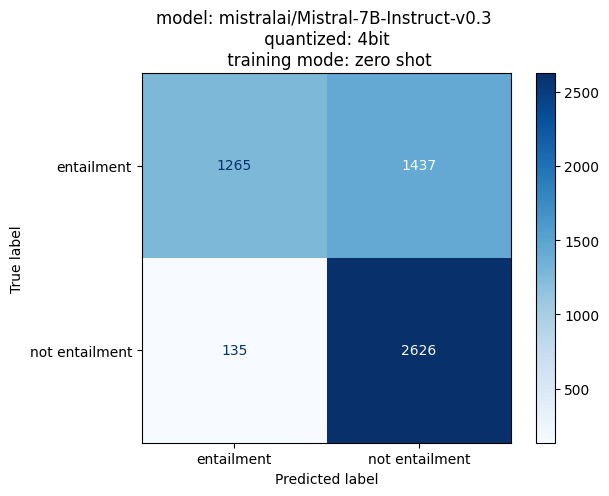

In [3]:
# Calculate metrics with padding_side=left
predicted_labels, gold_labels, batch = utils.load_checkpoint(checkpoint_path)
utils.evaluate_metrics(predicted_labels=predicted_labels, gold_labels=gold_labels, params=global_params)

Checkpoint found.
Accuracy: 0.7862.
 F1 Score: 0.7859.
 Matthew's Correlation Coefficient: 0.5750.
 Cohen's Kappa Score: 0.5727.


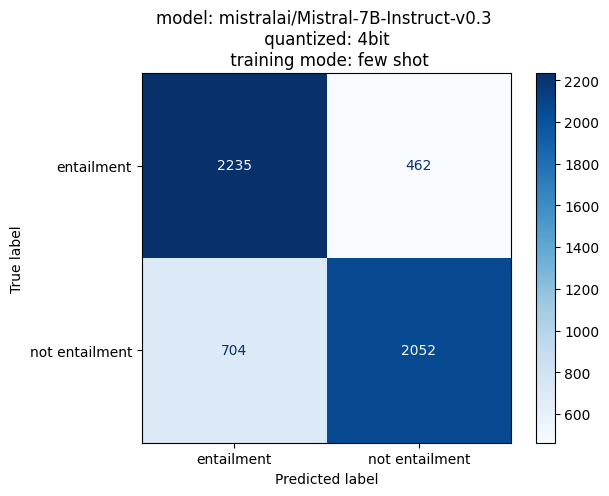

In [3]:
# Calculate metrics
predicted_labels, gold_labels, batch = utils.load_checkpoint(checkpoint_path)
utils.evaluate_metrics(predicted_labels=predicted_labels, gold_labels=gold_labels, params=global_params)